In [1]:
import SensoriMotorPrediction.globals as gl
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from SensoriMotorPrediction.vis import plot_heatmap_transitions
from scipy import stats

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


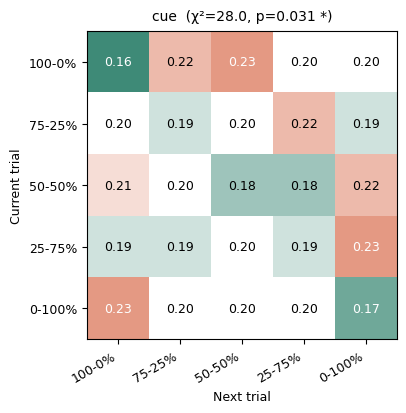

In [ ]:
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
df = pd.read_csv(filepath, sep='\t', )
df.cue = pd.Categorical(df.cue, categories=gl.cues, ordered=True)

col = 'cue'
probs, counts = [], []
for (sn, bn), block in df.groupby(["sn", "BN"]):
    curr = block[col].iloc[:-1].values
    nxt  = block[col].iloc[1:].values
    counts_tmp = pd.crosstab(curr, nxt)
    probs_tmp  = counts_tmp.div(counts_tmp.sum(axis=1), axis=0)
    counts.append(counts_tmp)
    probs.append(probs_tmp)

probs_avg = pd.concat(probs).groupby(level=0).mean().round(2)
counts_tot = pd.concat(counts).groupby(level=0).sum()
chi2, p, dof, _ = stats.chi2_contingency(counts_tot)

fig, ax = plt.subplots(figsize=(4, 4))
plot_heatmap_transitions(fig, ax, probs_avg, chi2, p, col)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

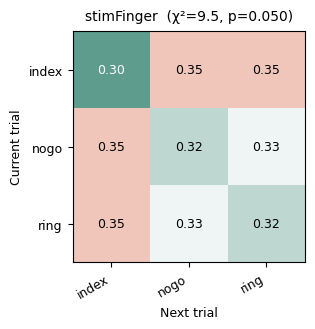

In [ ]:
col = 'stimFinger'
probs, counts = [], []
for (sn, bn), block in df.groupby(["sn", "BN"]):
    curr = block[col].iloc[:-1].values
    nxt  = block[col].iloc[1:].values
    counts_tmp = pd.crosstab(curr, nxt)
    probs_tmp  = counts_tmp.div(counts_tmp.sum(axis=1), axis=0)
    counts.append(counts_tmp)
    probs.append(probs_tmp)

probs_avg = pd.concat(probs).groupby(level=0).mean().round(2)
counts_tot = pd.concat(counts).groupby(level=0).sum()
chi2, p, dof, _ = stats.chi2_contingency(counts_tot)

fig, ax = plt.subplots(figsize=(3, 3))
plot_heatmap_transitions(fig, ax, probs_avg, chi2, p, col)
plt.show()

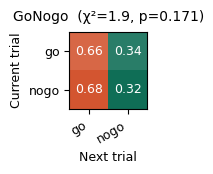

In [19]:
col = 'GoNogo'
probs, counts = [], []
for (sn, bn), block in df.groupby(["sn", "BN"]):
    curr = block[col].iloc[:-1].values
    nxt  = block[col].iloc[1:].values
    counts_tmp = pd.crosstab(curr, nxt)
    probs_tmp  = counts_tmp.div(counts_tmp.sum(axis=1), axis=0)
    counts.append(counts_tmp)
    probs.append(probs_tmp)

probs_avg = pd.concat(probs).groupby(level=0).mean().round(2)
counts_tot = pd.concat(counts).groupby(level=0).sum()
chi2, p, dof, _ = stats.chi2_contingency(counts_tot)

fig, ax = plt.subplots(figsize=(1, 1))
plot_heatmap_transitions(fig, ax, probs_avg, chi2, p, col)
plt.show()